In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import copy

# --- 1. DATA LOADING ---
df = pd.read_csv('merged.csv')
df['Stock_Timestamp'] = pd.to_datetime(df['Stock_Timestamp'], utc=True)
df = df.sort_values('Stock_Timestamp').reset_index(drop=True)

# --- 2. BASELINE FEATURES (OHLCV ONLY) ---
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Target: 1 if Next Close > Next Open (Matches T+1 Open entry execution)
df['Target'] = (df['Close'].shift(-1) > df['Open'].shift(-1)).astype(int)
model_df = df[feature_cols + ['Target']].dropna()

# --- 3. CHRONOLOGICAL SPLIT (70/20/10) ---
n = len(model_df)
train_idx = int(n * 0.70)
val_idx = int(n * 0.90)

# Sequence Creation
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_all, y_all = create_sequences(model_df[feature_cols].values, model_df['Target'].values, 10)

X_train_raw, y_train = X_all[:train_idx], y_all[:train_idx]
X_val_raw, y_val = X_all[train_idx:val_idx], y_all[train_idx:val_idx]
X_test_raw, y_test = X_all[val_idx:], y_all[val_idx:]

# --- 4. SCALING (FIT ONLY ON TRAIN) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw.reshape(-1, 5)).reshape(X_train_raw.shape)
X_val = scaler.transform(X_val_raw.reshape(-1, 5)).reshape(X_val_raw.shape)
X_test = scaler.transform(X_test_raw.reshape(-1, 5)).reshape(X_test_raw.shape)

# Convert to PyTorch Loaders
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)), batch_size=64, shuffle=False)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)), batch_size=64, shuffle=False)

In [2]:
# --- 5. MODEL COMPONENTS ---
def squash(x):
    s_sq_norm = torch.sum(x**2, dim=-1, keepdim=True)
    return (s_sq_norm / (1 + s_sq_norm)) * (x / torch.sqrt(s_sq_norm + 1e-9))

class CapsuleLayer(nn.Module):
    def __init__(self, num_capsules=8, num_route_nodes=10, in_channels=64, out_channels=16):
        super().__init__()
        # Dynamic routing parameters
        self.W = nn.Parameter(torch.randn(num_capsules, num_route_nodes, in_channels, out_channels))
        
    def forward(self, x):
        x = x[:, None, :, :, None]
        u_hat = torch.matmul(self.W[None, ...].transpose(-1, -2), x).squeeze(-1)
        b_ij = torch.zeros(u_hat.size(0), 8, 10).to(x.device) # Routing logits
        
        for i in range(3): # 3 iterations of dynamic routing
            c_ij = F.softmax(b_ij, dim=1)
            v_j = squash((c_ij[:, :, :, None] * u_hat).sum(dim=2))
            if i < 2: b_ij = b_ij + (u_hat * v_j[:, :, None, :]).sum(dim=-1)
        return v_j

class HybridCapsNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.caps = CapsuleLayer(8, 10, 64, 16)
        self.lstm = nn.LSTM(16, 32, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(32, 2)
        
    def forward(self, x):
        # 1D Conv -> Primary Capsules -> LSTM Temporal Integration
        x = F.relu(self.conv(x.transpose(1, 2))).transpose(1, 2)
        v_j = self.caps(x)
        _, (h_n, _) = self.lstm(v_j)
        return F.softmax(self.fc(h_n[-1]), dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridCapsNet(input_dim=5).to(device)

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [3]:
# --- 6. TRAINING LOOP ---
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()
EPOCHS = 30
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    
    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for v_data, v_target in val_loader:
            v_data, v_target = v_data.to(device), v_target.to(device)
            v_output = model(v_data)
            preds = torch.argmax(v_output, dim=1)
            correct += (preds == v_target).sum().item()
    
    val_acc = correct / (len(val_loader) * 64)
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_wts)



<All keys matched successfully>

In [4]:
# --- 7. STATISTICAL RESULTS ---
model.eval()
y_pred_probs = []
with torch.no_grad():
    for t_data, _ in test_loader:
        t_data = t_data.to(device)
        y_pred_probs.extend(model(t_data).cpu().numpy()[:, 1])

y_pred = (np.array(y_pred_probs) > 0.50).astype(int)

print("\n" + "="*50)
print("     CAPSNET-LSTM BASELINE STATISTICAL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down/Flat', 'Up']))


     CAPSNET-LSTM BASELINE STATISTICAL PERFORMANCE
Test Accuracy: 49.05%

Classification Report:
              precision    recall  f1-score   support

   Down/Flat       0.49      0.39      0.43      4517
          Up       0.49      0.60      0.54      4472

    accuracy                           0.49      8989
   macro avg       0.49      0.49      0.49      8989
weighted avg       0.49      0.49      0.48      8989




       CAPSNET-LSTM BASELINE FINANCIAL PERFORMANCE
Initial Capital:         $10,000.00
Total Net Profit:        $-2,225.98
Final Capital:           $7,774.02
Total ROI:               -22.26%


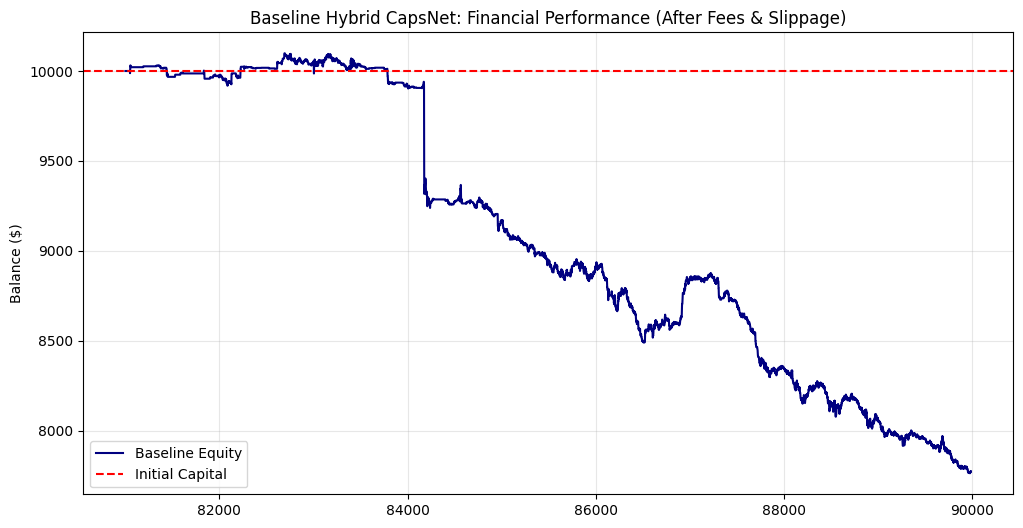

In [6]:
# --- 8. REALISTIC FINANCIAL SIMULATION ---
# Align testing indices with prices
df_test = model_df.iloc[val_idx + 10:].copy() # Offset by window size
df_test['Prob_Up'] = y_pred_probs
df_test['Signal'] = (df_test['Prob_Up'] > 0.50).astype(int) # Confidence threshold

# SLIPPAGE: Entry at Next Open, Exit at Next Close
df_test['Entry_Price'] = df_test['Open'].shift(-1)
df_test['Exit_Price'] = df_test['Close'].shift(-1)
df_test = df_test.dropna(subset=['Entry_Price', 'Exit_Price'])

INITIAL_CAPITAL = 10000.0
FEE_PER_SHARE = 0.009
current_capital = INITIAL_CAPITAL
capital_history = []

for idx, row in df_test.iterrows():
    if row['Signal'] == 1:
        # Full reinvestment compounding
        shares = np.floor(current_capital / row['Entry_Price'])
        
        # Net PnL = (Price Change * Shares) - (Fees)
        gross_pnl = (row['Exit_Price'] - row['Entry_Price']) * shares
        fees = shares * FEE_PER_SHARE
        
        current_capital += (gross_pnl - fees)
    
    capital_history.append(current_capital)

df_test['Account_Balance'] = capital_history
profit = current_capital - INITIAL_CAPITAL

print("\n" + "="*50)
print("       CAPSNET-LSTM BASELINE FINANCIAL PERFORMANCE")
print("="*50)
print(f"Initial Capital:         ${INITIAL_CAPITAL:,.2f}")
print(f"Total Net Profit:        ${profit:,.2f}")
print(f"Final Capital:           ${current_capital:,.2f}")
print(f"Total ROI:               {(profit/INITIAL_CAPITAL)*100:.2f}%")
print("="*50)

# --- 9. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['Account_Balance'], color='navy', label='Baseline Equity')
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', label='Initial Capital')
plt.title('Baseline Hybrid CapsNet: Financial Performance (After Fees & Slippage)')
plt.ylabel('Balance ($)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()